# From Biology to ML: Foundational Functions from Scratch

Much of machine learning is borrowed biology. The neuron, the learning rule, the
competition between units, the population that adapts over generations — each began as a
model of a **naturally occurring biological process** and became a core tool of ML/AI.

This notebook implements seven of them **from scratch** with only NumPy. As in the
XGBoost, GNN, and Random Forest notebooks, each topic is first written as **mathematics**
in a markdown cell, then implemented in the **code cell** that follows, with the
biological origin, the ML/AI connection, and the reasoning made explicit.

| # | Biological process | Function we implement | ML / AI descendant |
|---|--------------------|-----------------------|--------------------|
| 1 | Self-limiting population growth | Logistic / sigmoid | Activation functions |
| 2 | A spiking neuron's membrane | Leaky integrate-and-fire | The artificial neuron, SNNs |
| 3 | "Neurons that fire together wire together" | Hebbian / Oja's rule | Unsupervised learning ≡ PCA |
| 4 | Thermodynamic state occupancy | Softmax / Boltzmann | Classification, attention, RL policy |
| 5 | Predator–prey balance | Lotka–Volterra | Adversarial (GAN) dynamics |
| 6 | Morphogenesis (how patterns form) | Reaction–diffusion | Diffusion models, self-organization |
| 7 | Natural selection | Genetic algorithm | Neuroevolution, black-box optimization |

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.RandomState(0)
np.set_printoptions(precision=4, suppress=True)

## 1. The logistic function: self-limiting growth → activations

**Biology.** A population $N(t)$ with growth rate $r$ cannot grow forever; resources cap
it at a *carrying capacity* $K$. Verhulst's **logistic growth** says the per-capita rate
slows as the population fills the niche:

$$
\frac{dN}{dt} = r\,N\left(1 - \frac{N}{K}\right).
$$

Solving this ODE gives an **S-shaped (sigmoidal)** curve:

$$
N(t) = \frac{K}{1 + \big(\tfrac{K-N_0}{N_0}\big)e^{-rt}} .
$$

**The ML function.** Normalize ($K=1$, centered) and you get the **logistic / sigmoid**
activation and its tidy derivative:

$$
\sigma(x) = \frac{1}{1+e^{-x}}, \qquad \sigma'(x) = \sigma(x)\,\big(1-\sigma(x)\big).
$$

**Reasoning.** The same S-curve that describes a saturating population describes a
*saturating neuron*: small inputs grow nearly linearly, large inputs flatten out
(bounded output). That boundedness is exactly what makes the sigmoid a usable squashing
nonlinearity and a probability ($0<\sigma<1$). The derivative $\sigma(1-\sigma)$ is the
same logistic-loss hessian we used in the XGBoost notebook — biology and the loss
function meet at one curve.

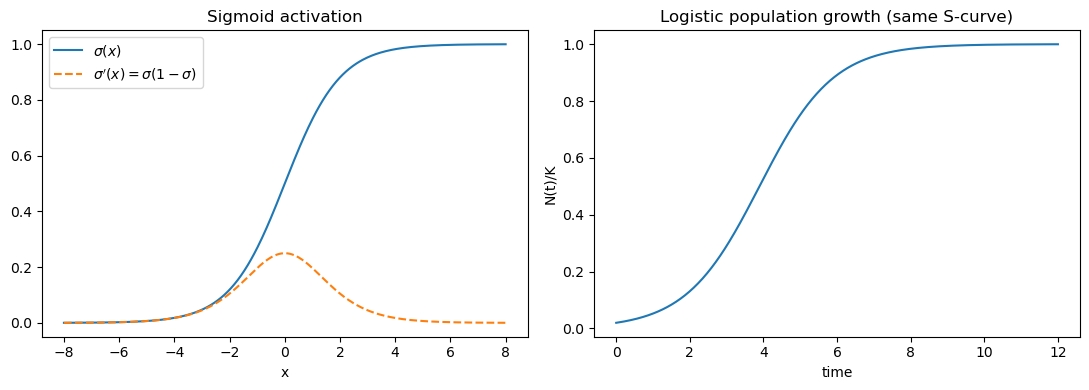

identical shapes: a saturating neuron is a saturating population.


In [2]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def sigmoid_deriv(s):           # given s = sigmoid(x)
    return s * (1.0 - s)

def logistic_growth(t, r=1.0, K=1.0, N0=0.02):
    return K / (1.0 + ((K - N0) / N0) * np.exp(-r * t))

x = np.linspace(-8, 8, 400)
s = sigmoid(x)
t = np.linspace(0, 12, 400)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(x, s, label=r"$\sigma(x)$")
ax[0].plot(x, sigmoid_deriv(s), "--", label=r"$\sigma'(x)=\sigma(1-\sigma)$")
ax[0].set_title("Sigmoid activation"); ax[0].set_xlabel("x"); ax[0].legend()

ax[1].plot(t, logistic_growth(t, r=1.0, K=1.0, N0=0.02))
ax[1].set_title("Logistic population growth (same S-curve)")
ax[1].set_xlabel("time"); ax[1].set_ylabel("N(t)/K")
plt.tight_layout(); plt.show()

print("identical shapes: a saturating neuron is a saturating population.")

## 2. The leaky integrate-and-fire neuron → the artificial neuron

**Biology.** A neuron's membrane behaves like a leaky capacitor. With membrane time
constant $\tau_m$, resting potential $V_{\text{rest}}$, input resistance $R$ and injected
current $I(t)$, the sub-threshold voltage obeys

$$
\tau_m \frac{dV}{dt} = -\big(V - V_{\text{rest}}\big) + R\,I(t).
$$

When $V$ crosses a threshold $V_{\text{th}}$, the neuron **fires a spike** and resets to
$V_{\text{reset}}$. Integrating constant input gives a **firing-rate vs input** ("f–I")
curve: zero below a rheobase current, then a rising, gently saturating response.

**The ML function.** The artificial neuron $y = \sigma(\mathbf{w}^\top\mathbf{x}+b)$ is a
*rate abstraction* of this: the dot product is the integrated input current, and the
activation $\sigma$ is the f–I curve. ReLU, in particular, mimics the thresholded,
roughly linear-above-rheobase shape.

**Reasoning.** We will simulate the membrane ODE with the explicit Euler step
$V \leftarrow V + \frac{\Delta t}{\tau_m}\big(-(V-V_{\text{rest}})+RI\big)$, record spikes,
and plot the f–I curve. Seeing a threshold-linear-saturating curve *emerge* from a simple
leaky ODE is the whole justification for using a static nonlinearity in a deep net.

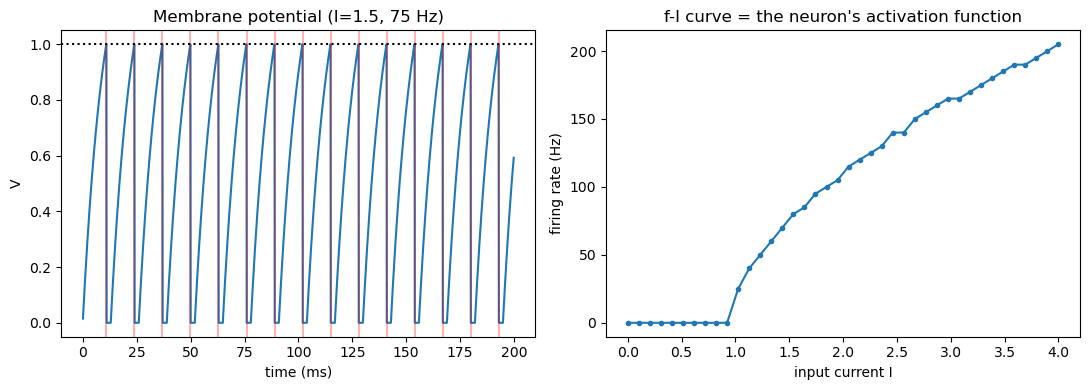

Note the rheobase threshold then near-linear rise: a biological ReLU.


In [3]:
def lif_simulate(I, dt=0.1, T=200.0, tau=10.0, R=1.0,
                 V_rest=0.0, V_th=1.0, V_reset=0.0, t_ref=2.0):
    """Simulate one LIF neuron under constant input current I (ms units)."""
    n_steps = int(T / dt)
    V = V_rest
    refractory = 0.0
    trace, spikes = [], []
    for k in range(n_steps):
        if refractory > 0:
            V = V_reset; refractory -= dt
        else:
            V += dt / tau * (-(V - V_rest) + R * I)
            if V >= V_th:
                spikes.append(k * dt); V = V_th  # mark spike for the plot
                refractory = t_ref
        trace.append(V)
    rate = len(spikes) / (T / 1000.0)            # spikes per second (Hz)
    return np.array(trace), np.array(spikes), rate

# one example voltage trace
trace, spikes, rate = lif_simulate(I=1.5)
ts = np.arange(len(trace)) * 0.1

# f-I curve: sweep the input current
currents = np.linspace(0, 4, 40)
rates = np.array([lif_simulate(I=I)[2] for I in currents])

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ts, trace)
for sp in spikes:
    ax[0].axvline(sp, color="r", alpha=0.3)
ax[0].axhline(1.0, ls=":", color="k")
ax[0].set_title(f"Membrane potential (I=1.5, {rate:.0f} Hz)")
ax[0].set_xlabel("time (ms)"); ax[0].set_ylabel("V")

ax[1].plot(currents, rates, "-o", ms=3)
ax[1].set_title("f-I curve = the neuron's activation function")
ax[1].set_xlabel("input current I"); ax[1].set_ylabel("firing rate (Hz)")
plt.tight_layout(); plt.show()

print("Note the rheobase threshold then near-linear rise: a biological ReLU.")

## 3. Hebbian learning and Oja's rule → unsupervised learning = PCA

**Biology.** Hebb's postulate (1949): *"neurons that fire together wire together."* If a
presynaptic input $\mathbf{x}$ and the postsynaptic output $y=\mathbf{w}^\top\mathbf{x}$
are active together, strengthen the synapse:

$$
\Delta \mathbf{w} = \eta\, y\, \mathbf{x}.
$$

Pure Hebb is **unstable** — weights grow without bound. Oja (1982) added a built-in
normalization (a decay term proportional to $y^2$):

$$
\Delta \mathbf{w} = \eta\, y\,\big(\mathbf{x} - y\,\mathbf{w}\big).
$$

**The ML function.** Oja's rule provably converges to the **top principal component** of
the input: $\mathbf{w}$ aligns with the leading eigenvector of the covariance
$C=\mathbb{E}[\mathbf{x}\mathbf{x}^\top]$, with $\lVert\mathbf{w}\rVert\to 1$. So a single
biologically plausible neuron performs **online PCA** — the root of unsupervised
representation learning.

**Reasoning.** No labels, no gradients of a loss — just local correlation plus
normalization. We will feed correlated 2-D data one sample at a time and watch
$\mathbf{w}$ rotate onto the principal axis, then confirm it matches the dominant
eigenvector of the covariance matrix.

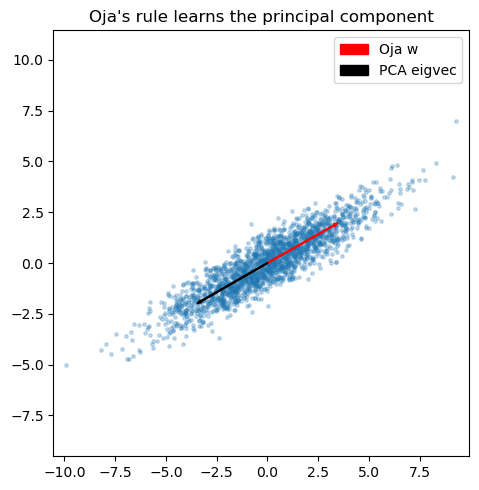

||w|| = 1.000  (Oja self-normalizes to 1)
cosine similarity between Oja w and PCA eigenvector: 1.0000


In [4]:
# correlated 2-D data: stretch + rotate isotropic Gaussian
theta = np.deg2rad(30)
Rot = np.array([[np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]])
Xdata = (rng.randn(2000, 2) * np.array([3.0, 0.6])) @ Rot.T
Xdata -= Xdata.mean(0)

# Oja's rule, online
w = rng.randn(2); w /= np.linalg.norm(w)
eta = 0.001
for x_i in Xdata:
    y = w @ x_i                      # postsynaptic activity
    w = w + eta * y * (x_i - y * w)  # Hebb + Oja normalization

# ground-truth top principal component (eigvec of covariance)
C = np.cov(Xdata.T)
evals, evecs = np.linalg.eigh(C)
pc1 = evecs[:, np.argmax(evals)]
cos_sim = abs(w @ pc1) / (np.linalg.norm(w) * np.linalg.norm(pc1))

plt.figure(figsize=(5, 5))
plt.scatter(Xdata[:, 0], Xdata[:, 1], s=6, alpha=0.25)
for vec, lab, c in [(w, "Oja w", "r"), (pc1, "PCA eigvec", "k")]:
    plt.arrow(0, 0, 4*vec[0], 4*vec[1], width=0.05, color=c, label=lab,
              length_includes_head=True)
plt.legend(); plt.axis("equal"); plt.title("Oja's rule learns the principal component")
plt.tight_layout(); plt.show()

print(f"||w|| = {np.linalg.norm(w):.3f}  (Oja self-normalizes to 1)")
print(f"cosine similarity between Oja w and PCA eigenvector: {cos_sim:.4f}")

## 4. The Boltzmann distribution → softmax (classification, attention, RL)

**Biology / physics.** In a system at temperature $T$, the probability of occupying a
state with energy $E_i$ follows the **Boltzmann distribution**:

$$
P(i) = \frac{e^{-E_i/T}}{\sum_j e^{-E_j/T}} .
$$

Pools of competing neurons behave the same way: higher "drive" (lower energy) wins more
often, but noise (temperature) keeps it stochastic — a soft winner-take-all.

**The ML function.** Set the score / logit $z_i = -E_i$ and you get the **softmax**:

$$
\mathrm{softmax}(z)_i = \frac{e^{z_i/T}}{\sum_j e^{z_j/T}} .
$$

It is the output layer of every classifier, the weighting in **attention**
($\mathrm{softmax}(QK^\top/\sqrt{d})$), and the policy in **Boltzmann-exploration** RL.

**Reasoning.** The **temperature** $T$ is the dial between exploitation and exploration:
$T\to 0$ gives a hard argmax (one winner), $T\to\infty$ gives the uniform distribution
(all equal). We will plot one fixed set of logits at several temperatures to see that
sharpening/softening directly — the same knob used to control sampling diversity in LLMs.

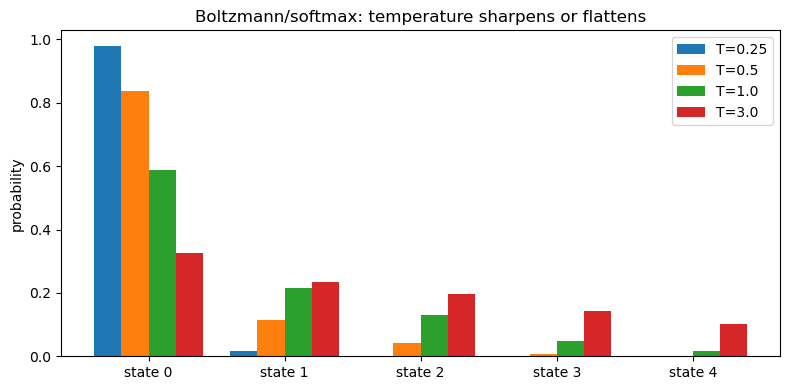

T->0  : argmax (winner-take-all) -> [1. 0. 0. 0. 0.]
T->inf: uniform                  -> [0.21 0.2  0.2  0.2  0.19]


In [5]:
def softmax(z, T=1.0):
    z = np.asarray(z, dtype=float) / T
    z = z - z.max()                      # numerical stability
    e = np.exp(z)
    return e / e.sum()

logits = np.array([3.0, 2.0, 1.5, 0.5, -0.5])
temps = [0.25, 0.5, 1.0, 3.0]

plt.figure(figsize=(8, 4))
width = 0.2
idx = np.arange(len(logits))
for j, T in enumerate(temps):
    plt.bar(idx + j*width, softmax(logits, T), width, label=f"T={T}")
plt.xticks(idx + 1.5*width, [f"state {i}" for i in idx])
plt.ylabel("probability"); plt.title("Boltzmann/softmax: temperature sharpens or flattens")
plt.legend(); plt.tight_layout(); plt.show()

print("T->0  : argmax (winner-take-all) ->", softmax(logits, 0.05).round(2))
print("T->inf: uniform                  ->", softmax(logits, 50).round(2))

## 5. Lotka–Volterra predator–prey → adversarial (GAN) dynamics

**Biology.** Two interacting populations — prey $x$ and predator $y$ — obey the
**Lotka–Volterra** equations:

$$
\frac{dx}{dt} = \alpha x - \beta x y, \qquad
\frac{dy}{dt} = \delta x y - \gamma y .
$$

Prey grow ($\alpha$) but are eaten ($\beta$); predators die off ($\gamma$) but grow by
eating ($\delta$). The system never settles — it traces **closed orbits**: prey boom,
predators follow, prey crash, predators starve, repeat.

**The ML function.** This is the textbook picture of a **two-player min-max game**, the
dynamics of **GAN** training: the generator (prey) and discriminator (predator) chase
each other, and the "equilibrium" is an *orbit*, not a fixed point — which is exactly why
GANs oscillate and are hard to converge. Same math underlies multi-agent RL co-adaptation.

**Reasoning.** We integrate the ODEs with **RK4** (4th-order Runge–Kutta) for accuracy and
plot both the time series and the **phase portrait**. The closed loop in phase space is
the visual signature of adversarial, non-converging dynamics — a caution we inherit
straight from ecology.

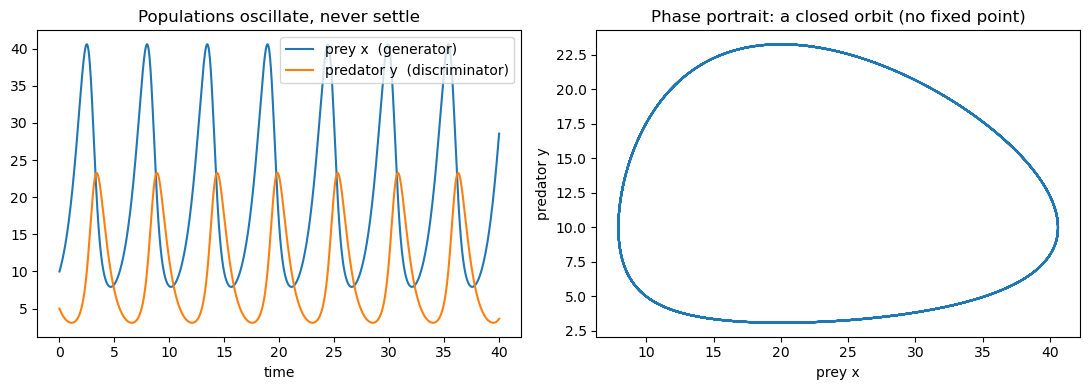

GANs inherit this: the 'equilibrium' is an orbit, hence the oscillation.


In [6]:
def lotka_volterra(state, alpha=1.0, beta=0.1, delta=0.075, gamma=1.5):
    x, y = state
    return np.array([alpha*x - beta*x*y,
                     delta*x*y - gamma*y])

def rk4(f, s0, dt, n):
    traj = np.empty((n, len(s0)))
    s = np.array(s0, dtype=float)
    for k in range(n):
        traj[k] = s
        k1 = f(s)
        k2 = f(s + 0.5*dt*k1)
        k3 = f(s + 0.5*dt*k2)
        k4 = f(s + dt*k3)
        s = s + dt/6.0 * (k1 + 2*k2 + 2*k3 + k4)
    return traj

dt, n = 0.01, 4000
traj = rk4(lotka_volterra, [10.0, 5.0], dt, n)
time = np.arange(n) * dt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(time, traj[:, 0], label="prey x  (generator)")
ax[0].plot(time, traj[:, 1], label="predator y  (discriminator)")
ax[0].set_xlabel("time"); ax[0].set_title("Populations oscillate, never settle")
ax[0].legend()
ax[1].plot(traj[:, 0], traj[:, 1])
ax[1].set_xlabel("prey x"); ax[1].set_ylabel("predator y")
ax[1].set_title("Phase portrait: a closed orbit (no fixed point)")
plt.tight_layout(); plt.show()

print("GANs inherit this: the 'equilibrium' is an orbit, hence the oscillation.")

## 6. Reaction–diffusion → diffusion models & self-organization

**Biology.** How does a uniform ball of cells grow spots and stripes? Turing (1952)
showed that two chemicals — an activator $U$ and inhibitor $V$ — that **react** and
**diffuse** at different rates can spontaneously break symmetry. The Gray–Scott model:

$$
\frac{\partial U}{\partial t} = D_u \nabla^2 U - U V^2 + F\,(1-U), \qquad
\frac{\partial V}{\partial t} = D_v \nabla^2 V + U V^2 - (F+k)\,V .
$$

$\nabla^2$ is the Laplacian (diffusion); $UV^2$ is the autocatalytic reaction; $F$ feeds
$U$ and $k$ removes $V$. From an almost-uniform start, rich **patterns emerge**.

**The ML function.** Two lineages descend from this: (1) **diffusion generative models**,
which generate images by reversing a diffusion process — structure emerging from noise
through iterated local updates; and (2) **neural cellular automata / self-organizing
systems**, where global form arises from purely local rules.

**Reasoning.** We discretize space on a grid, approximate $\nabla^2$ with the 5-point
stencil (via `np.roll`, periodic boundaries), and step the PDE explicitly. Watching
order crystallize out of a noisy field is the intuition behind generation as iterative
refinement (structure from noise).

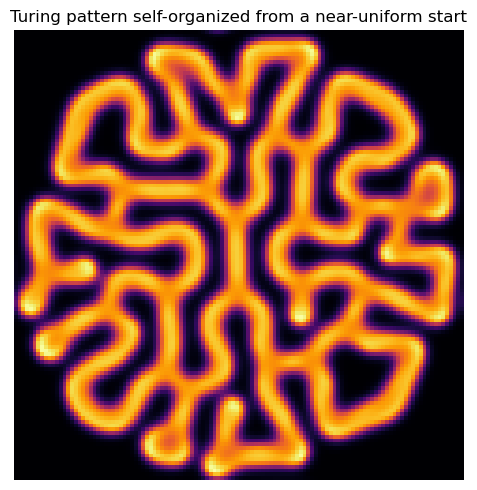

Structure from noise via iterated local updates -- the diffusion-model intuition.


In [7]:
def laplacian(Z):
    # 5-point stencil with periodic (wrap-around) boundaries
    return (np.roll(Z, 1, 0) + np.roll(Z, -1, 0) +
            np.roll(Z, 1, 1) + np.roll(Z, -1, 1) - 4*Z)

def gray_scott(size=120, steps=6000, Du=0.16, Dv=0.08, F=0.060, k=0.062, seed=0):
    r = np.random.RandomState(seed)
    U = np.ones((size, size)); V = np.zeros((size, size))
    # seed a small central square with the inhibitor, plus a little noise
    c = size // 2; rad = 8
    U[c-rad:c+rad, c-rad:c+rad] = 0.50
    V[c-rad:c+rad, c-rad:c+rad] = 0.25
    U += 0.02 * r.randn(size, size); V += 0.02 * r.randn(size, size)
    for _ in range(steps):
        uvv = U * V * V
        U += Du * laplacian(U) - uvv + F * (1 - U)
        V += Dv * laplacian(V) + uvv - (F + k) * V
        np.clip(U, 0, 1, out=U); np.clip(V, 0, 1, out=V)
    return V

pattern = gray_scott()
plt.figure(figsize=(5, 5))
plt.imshow(pattern, cmap="inferno")
plt.title("Turing pattern self-organized from a near-uniform start")
plt.axis("off"); plt.tight_layout(); plt.show()

print("Structure from noise via iterated local updates -- the diffusion-model intuition.")

## 7. The genetic algorithm → gradient-free optimization / neuroevolution

**Biology.** Evolution optimizes without gradients. A **population** of candidate
solutions is scored by a **fitness** function; the fittest are **selected** to reproduce;
offspring **recombine** their parents (crossover) and **mutate**; repeat. Over generations
the population climbs the fitness landscape.

For a population $\{\theta_i\}$ with fitness $f(\theta_i)$, one generation is:

$$
\underbrace{\text{select parents} \propto f}_{\text{survival}}
\;\to\;
\underbrace{\theta_{\text{child}} = \text{crossover}(\theta_a,\theta_b)}_{\text{recombination}}
\;\to\;
\underbrace{\theta_{\text{child}} \mathrel{+}= \mathcal{N}(0,\sigma^2)}_{\text{mutation}} .
$$

**The ML function.** When gradients are unavailable, noisy, or the objective is
non-differentiable (reward in RL, architecture choices, hyper-parameters), evolution is a
go-to optimizer: **neuroevolution**, evolution strategies, and black-box search all run
this loop.

**Reasoning.** We minimize the **Rastrigin** function — a notoriously multimodal landscape
($f=10n+\sum_i [x_i^2 - 10\cos 2\pi x_i]$, global min $0$ at the origin) that traps
gradient methods in local minima. The population's diversity lets it tunnel past those
traps; we watch best fitness fall toward zero over generations.

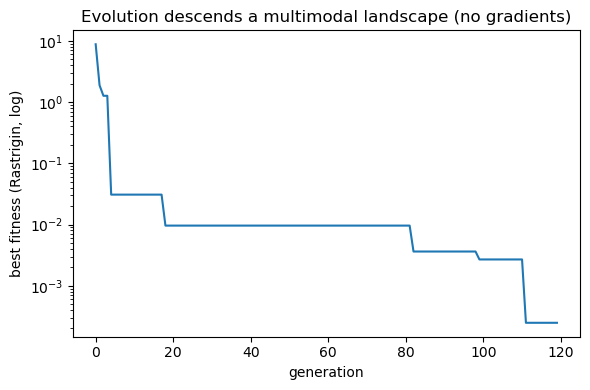

best solution found: [-0.0011  0.0001]   (global optimum is the origin)
best fitness: 0.0002   (global minimum is 0)


In [8]:
def rastrigin(X):                    # X: (pop, dim); global min 0 at origin
    return 10*X.shape[1] + np.sum(X**2 - 10*np.cos(2*np.pi*X), axis=1)

def genetic_algorithm(dim=2, pop=200, generations=120, bounds=5.12,
                      mut_sigma=0.3, elite_frac=0.1, seed=0):
    r = np.random.RandomState(seed)
    P = r.uniform(-bounds, bounds, size=(pop, dim))
    n_elite = max(1, int(elite_frac * pop))
    best_hist = []
    for g in range(generations):
        fit = rastrigin(P)                       # lower is better
        order = np.argsort(fit)
        P = P[order]                             # sort best-first
        best_hist.append(fit[order[0]])
        elite = P[:n_elite]
        # tournament selection from the better half
        def tournament():
            i, j = r.randint(0, pop//2, size=2)
            return P[min(i, j)]
        children = [elite[e] for e in range(n_elite)]
        while len(children) < pop:
            a, b = tournament(), tournament()
            mask = r.rand(dim) < 0.5              # uniform crossover
            child = np.where(mask, a, b)
            child = child + r.randn(dim) * mut_sigma   # Gaussian mutation
            children.append(np.clip(child, -bounds, bounds))
        P = np.array(children)
    return P[np.argmin(rastrigin(P))], np.array(best_hist)

best, hist = genetic_algorithm()
plt.figure(figsize=(6, 4))
plt.plot(hist)
plt.yscale("log")
plt.xlabel("generation"); plt.ylabel("best fitness (Rastrigin, log)")
plt.title("Evolution descends a multimodal landscape (no gradients)")
plt.tight_layout(); plt.show()

print(f"best solution found: {best}   (global optimum is the origin)")
print(f"best fitness: {rastrigin(best[None])[0]:.4f}   (global minimum is 0)")

## Summary

Seven natural processes, seven functions at the heart of ML/AI:

| Biological process | Function | Key equation | ML/AI descendant |
|---|---|---|---|
| Self-limiting growth | sigmoid | $\sigma(x)=\frac{1}{1+e^{-x}}$ | activations, probabilities |
| Spiking membrane | leaky integrate-fire | $\tau_m\dot V=-(V{-}V_{\text{rest}})+RI$ | the artificial neuron, SNNs |
| "Fire together, wire together" | Oja's rule | $\Delta w=\eta y(x-yw)$ | online PCA / unsupervised learning |
| Thermodynamic occupancy | softmax | $\frac{e^{z_i/T}}{\sum_j e^{z_j/T}}$ | classification, attention, RL policy |
| Predator–prey | Lotka–Volterra | $\dot x=\alpha x-\beta xy$ | GAN / adversarial dynamics |
| Morphogenesis | reaction–diffusion | $\partial_t U=D\nabla^2U+\text{react}$ | diffusion models, self-organization |
| Natural selection | genetic algorithm | select $\propto f$, recombine, mutate | neuroevolution, black-box optimization |

A few threads tie them together:

- **Saturation and thresholds** (1, 2) give neurons their nonlinearity — without it, deep
  nets collapse to a single linear map.
- **Local rules → global structure** (3, 6) is the same principle behind unsupervised
  representation learning and generative diffusion: no global supervisor, yet order
  emerges.
- **Competition and balance** (4, 5) — soft winner-take-all and adversarial orbits — show
  up wherever units or agents must share probability mass or fight to a stalemate.
- **Population search** (7) is evolution's answer to optimization when calculus (gradients)
  is unavailable.

Biology got there first; ML rediscovered these functions because they are the robust,
general solutions to integrating signals, learning from correlation, choosing among
options, balancing adversaries, building structure, and searching without a map.